In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, KFold

In [2]:
no_dummies = pd.read_csv('Step 4 - Final Dataset without dummies.csv')

In [3]:
scout_car = pd.read_csv('Step 4 - Final Dataset with dummies.csv')
scout_car

,Price,KM,Registration,Horsepower (kW),Previous Owners,Inspection new,Warranty (months),# of Doors,# of Seats,Displacement (cc),...,Country version_Poland,Country version_Spain,Upholstery Material_Full leather,Upholstery Material_Other,Upholstery Material_Part leather,Upholstery Material_Velour,Upholstery Material_alcantara,Upholstery Color_Brown,Upholstery Color_Grey,Upholstery Color_Other
0,15770.0,56013.0,2016.0,66.0,2,1,0.0,5.0,5.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
1,14500.0,80000.0,2017.0,141.0,0,0,0.0,3.0,4.0,1798.0,...,0,0,0,0,0,0,0,0,1,0
2,14640.0,83450.0,2016.0,85.0,1,0,0.0,5.0,4.0,1598.0,...,0,0,0,0,0,0,0,0,0,0
3,14500.0,73000.0,2016.0,66.0,1,0,0.0,3.0,4.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
4,16790.0,16200.0,2016.0,66.0,1,1,0.0,5.0,5.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15095,39950.0,10.0,2016.0,147.0,0,0,0.0,5.0,5.0,1997.0,...,0,0,1,0,0,0,0,0,0,0
15096,39885.0,9900.0,2019.0,165.0,1,0,0.0,5.0,5.0,1798.0,...,0,0,0,0,0,0,0,0,0,0
15097,39875.0,15.0,2019.0,146.0,1,1,0.0,5.0,7.0,1997.0,...,0,0,1,0,0,0,0,0,0,0
15098,39700.0,10.0,2019.0,147.0,0,0,0.0,5.0,7.0,1997.0,...,0,0,0,0,1,0,0,0,0,0


In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from scipy import stats

# Features
X = scout_car.drop(columns=['Price'])

# Target
y = scout_car['Price']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rfr = RandomForestRegressor()
rfr.fit(X_train, y_train)

RandomForestRegressor()

In [5]:
y_pred = rfr.predict(X_test)
y_pred

array([34789.45, 11081.34, 38140.18, ..., 10985.18,  7309.78, 20408.96])

In [6]:
# Create a new DataFrame showing the samples indices next to the non-dummy columns.
# This will allow us to compare results side-by-side with these categorial columns.
samples_no_dummies = no_dummies.loc[X_test.index]

# Build a new DataFrame compiling the results of the Linear Regression for each sample.
# We can also load categorical columns into this DataFrame.
rfr_init_results = pd.DataFrame()
rfr_init_results['make_model'] = samples_no_dummies['make_model']
rfr_init_results['Actual Price'] = y_test
rfr_init_results['Predicted Price'] = np.round(y_pred).astype(int)
rfr_init_results['Error'] = rfr_init_results['Predicted Price'] - rfr_init_results['Actual Price']
rfr_init_results['Squared Error'] = rfr_init_results['Error'] ** 2
rfr_init_results['Absolute Error'] = rfr_init_results['Error'].abs()
rfr_init_results

,make_model,Actual Price,Predicted Price,Error,Squared Error,Absolute Error
14845,Renault Espace,34985.0,34789,-196.0,38416.0,196.0
14120,Renault Clio,11280.0,11081,-199.0,39601.0,199.0
14860,Renault Espace,38875.0,38140,-735.0,540225.0,735.0
884,Audi A1,14500.0,15489,989.0,978121.0,989.0
411,Audi A1,15900.0,16980,1080.0,1166400.0,1080.0
...,...,...,...,...,...,...
499,Audi A1,13700.0,13416,-284.0,80656.0,284.0
668,Audi A1,12451.0,12842,391.0,152881.0,391.0
8028,Opel Corsa,12990.0,10985,-2005.0,4020025.0,2005.0
8495,Opel Corsa,7650.0,7310,-340.0,115600.0,340.0


In [7]:
print(f"Mean squared error: {rfr_init_results['Squared Error'].mean()}")
print(f"Mean absolute error: {rfr_init_results['Absolute Error'].mean()}")
print(f"Median absolute error: {rfr_init_results['Absolute Error'].median()}")

Mean squared error: 2383883.601986755
Mean absolute error: 922.0172185430464
Median absolute error: 531.5


In [8]:
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}")
print(f"Median Absolute Error: {median_absolute_error(y_test, y_pred)}")

R2 Score: 0.9578751627018125
Mean Squared Error: 2383882.4254407138
Mean Absolute Error: 922.0234338750469
Median Absolute Error: 531.5500000000002


In [9]:
rfr_init_results.nsmallest(10, 'Absolute Error')

,make_model,Actual Price,Predicted Price,Error,Squared Error,Absolute Error
14111,Renault Clio,11290.0,11290,0.0,0.0,0.0
7144,Opel Astra,14800.0,14800,0.0,0.0,0.0
351,Audi A1,14990.0,14990,0.0,0.0,0.0
4800,Audi A3,27410.0,27410,0.0,0.0,0.0
13745,Renault Clio,9999.0,9999,0.0,0.0,0.0
2380,Audi A1,28820.0,28820,0.0,0.0,0.0
339,Audi A1,14990.0,14990,0.0,0.0,0.0
9808,Opel Corsa,10979.0,10979,0.0,0.0,0.0
290,Audi A1,15090.0,15090,0.0,0.0,0.0
12794,Renault Clio,8490.0,8490,0.0,0.0,0.0


In [10]:
(rfr_init_results[rfr_init_results['Absolute Error'] == 0]).count()

make_model         90
Actual Price       90
Predicted Price    90
Error              90
Squared Error      90
Absolute Error     90
dtype: int64

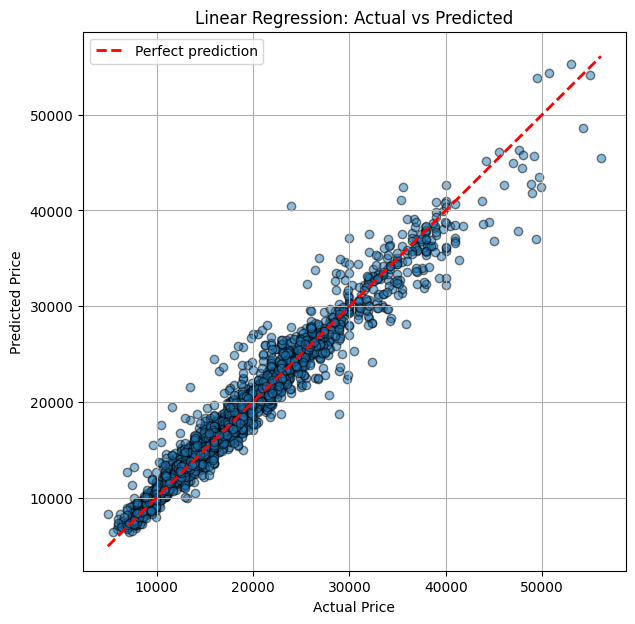

In [11]:
# Predictions on the test set
y_pred = rfr.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='black', linewidths=1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', linestyle='--', linewidth=2, label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

# RFR with K Fold

In [13]:
# Define K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation using R² score
cv_scores = cross_val_score(rfr, X, y, cv=kf, scoring='r2')

print("Cross-validation R² scores:", cv_scores)
print("Mean R²:", np.mean(cv_scores))
print("Standard deviation of R²:", np.std(cv_scores))

Cross-validation R² scores: [0.9578627  0.95058742 0.9531682  0.95214127 0.95108089]
Mean R²: 0.9529680962336006
Standard deviation of R²: 0.0026042288260512284


In [15]:
from sklearn.model_selection import cross_val_predict

# Generate out-of-fold predictions for all data
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_all = cross_val_predict(rfr, X, y, cv=kf)

# Build results dataframe
rfr_cv_results = pd.DataFrame()
rfr_cv_results['make_model'] = no_dummies['make_model']
rfr_cv_results['Actual Price'] = y
rfr_cv_results['Predicted Price'] = np.round(y_pred_all).astype(int)
rfr_cv_results['Error'] = rfr_cv_results['Predicted Price'] - rfr_cv_results['Actual Price']
rfr_cv_results['Squared Error'] = rfr_cv_results['Error'] ** 2
rfr_cv_results['Absolute Error'] = rfr_cv_results['Error'].abs()
rfr_cv_results

,make_model,Actual Price,Predicted Price,Error,Squared Error,Absolute Error
0,Audi A1,15770.0,16484,714.0,509796.0,714.0
1,Audi A1,14500.0,15009,509.0,259081.0,509.0
2,Audi A1,14640.0,14453,-187.0,34969.0,187.0
3,Audi A1,14500.0,14637,137.0,18769.0,137.0
4,Audi A1,16790.0,17063,273.0,74529.0,273.0
...,...,...,...,...,...,...
15095,Renault Espace,39950.0,40511,561.0,314721.0,561.0
15096,Renault Espace,39885.0,37066,-2819.0,7946761.0,2819.0
15097,Renault Espace,39875.0,38735,-1140.0,1299600.0,1140.0
15098,Renault Espace,39700.0,39802,102.0,10404.0,102.0


In [18]:
(rfr_cv_results[rfr_cv_results['Absolute Error'] == 0])['Absolute Error'].count()

np.int64(486)

486 cars out of 15100 were predicted perfectly.

# RFR with GridSearchCV